# Structural Analysis of the PubMed Dataset

This notebook performs a structural analysis of the PubMed dataset

In [1]:
import sys
import os
import time
import random
import json

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
from torch_geometric.transforms import NormalizeFeatures

import networkx as nx

In [2]:
sns.set_style("white")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": False
})

os.makedirs("../../results/plots/pubmed", exist_ok=True)
os.makedirs("../../results/tables/pubmed", exist_ok=True)

## Dataset

The experiments are conducted on the PubMed dataset

In [3]:
dataset = Planetoid(
    root="../../data",
    name="PubMed",
    transform=NormalizeFeatures()
)

data = dataset[0]

print(dataset)
print(data)

PubMed()
Data(x=[19717, 500], edge_index=[2, 88648], y=[19717], train_mask=[19717], val_mask=[19717], test_mask=[19717])


## Models

In [4]:
sys.path.append(os.path.abspath("../.."))

from src.models.node_classification import GCN, GraphSAGE, GAT

from src.training.train import train_node_classification
from src.training.evaluate import evaluate_node_classification

from src.utils.seed import set_seed

## Effect of Model Depth

The experiment evaluates GCN models with varying numbers of layers. The objective is to observe whether increasing the number of message-passing steps leads to improved performance or, alternatively, to performance degradation.

A consistent drop in accuracy for deeper models may indicate the presence of information bottlenecks that limit the effective propagation of signals through the graph.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}")

models = {
    "gcn": GCN,
    "graphsage": GraphSAGE,
    "gat": GAT
}

in_dim = dataset.num_features
num_classes = dataset.num_classes

hidden_dim = 64
epochs = 200
lr = 0.001
weight_decay = 5e-4
dropout = 0.5

layer_values = [2, 4, 6, 8]
seeds = [0, 7, 37, 42]

results = {m: {"layers": [], "acc_mean": [], "acc_std": [], "time": []} for m in models.keys()}
history = {}

data = data.to(device)

for model_name, ModelClass in models.items():

    print(f"\nRunning experiments for {model_name.upper()}")

    history[model_name] = {}

    for num_layers in layer_values:
        history[model_name][num_layers] = {}

        acc_runs = []
        time_runs = []

        for seed in seeds:

            set_seed(seed)

            model = ModelClass(in_dim, hidden_dim, num_classes, num_layers, dropout).to(device)

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=lr,
                weight_decay=weight_decay
            )

            start = time.time()

            hist = train_node_classification(
                model,
                data,
                optimizer,
                epochs=epochs
            )
            history[model_name][num_layers][seed] = hist

            end = time.time()
            elapsed = end - start

            acc = evaluate_node_classification(
                model,
                data
            )
            acc_runs.append(acc)
            time_runs.append(elapsed)

        # estadísticas
        acc_mean = np.mean(acc_runs)
        acc_std = np.std(acc_runs)

        results[model_name]["layers"].append(num_layers)
        results[model_name]["acc_mean"].append(acc_mean)
        results[model_name]["acc_std"].append(acc_std)
        results[model_name]["time"].append(np.mean(time_runs))

        print(
            f"Layers: {num_layers} | "
            f"Accuracy: {acc_mean:.4f} ± {acc_std:.4f}"
        )

Running on cuda

Running experiments for GCN


100%|██████████| 200/200 [00:02<00:00, 92.13it/s]


Layers: 2 | Accuracy: 0.7688 ± 0.0068


100%|██████████| 200/200 [00:04<00:00, 43.59it/s]


Layers: 4 | Accuracy: 0.7592 ± 0.0103


...

Layers: 4 | Accuracy: 0.7672 ± 0.0040


100%|██████████| 200/200 [00:31<00:00,  6.31it/s]


Layers: 6 | Accuracy: 0.7545 ± 0.0057


100%|██████████| 200/200 [00:43<00:00,  4.58it/s]

Layers: 8 | Accuracy: 0.7640 ± 0.0092


In [7]:
def plot_by_model(history, model_name):

    layers_list = sorted(history[model_name].keys())

    fig, axs = plt.subplots(2, len(layers_list), figsize=(5 * len(layers_list), 8))

    for i, num_layers in enumerate(layers_list):

        seeds = history[model_name][num_layers]

        train_loss = []
        val_loss = []
        train_acc = []
        val_acc = []

        for seed in seeds:
            h = seeds[seed]

            train_loss.append(h["train_loss"])
            train_acc.append(h["train_acc"])

            if "val_loss" in h:
                val_loss.append(h["val_loss"])
                val_acc.append(h["val_acc"])

        # --- convert to numpy ---
        train_loss = np.array(train_loss)
        train_acc = np.array(train_acc)

        # --- mean & std ---
        train_loss_mean = train_loss.mean(axis=0)
        train_loss_std = train_loss.std(axis=0)

        train_acc_mean = train_acc.mean(axis=0)
        train_acc_std = train_acc.std(axis=0)

        if len(val_loss) > 0:
            val_loss = np.array(val_loss)
            val_acc = np.array(val_acc)

            val_loss_mean = val_loss.mean(axis=0)
            val_loss_std = val_loss.std(axis=0)

            val_acc_mean = val_acc.mean(axis=0)
            val_acc_std = val_acc.std(axis=0)

        epochs = range(len(train_loss_mean))

        # =====================
        # ROW 1 → ACCURACY
        # =====================
        ax_acc = axs[0, i]

        ax_acc.plot(epochs, train_acc_mean, label="train")
        ax_acc.fill_between(
            epochs,
            train_acc_mean - train_acc_std,
            train_acc_mean + train_acc_std,
            alpha=0.2
        )

        if len(val_loss) > 0:
            ax_acc.plot(epochs, val_acc_mean, linestyle="--", label="val")
            ax_acc.fill_between(
                epochs,
                val_acc_mean - val_acc_std,
                val_acc_mean + val_acc_std,
                alpha=0.2
            )

        ax_acc.set_title(f"{num_layers} layers")
        ax_acc.set_xlabel("Epoch")
        ax_acc.set_ylabel("Accuracy")

        if i == 0:
            ax_acc.legend()

        # =====================
        # ROW 2 → LOSS
        # =====================
        ax_loss = axs[1, i]

        ax_loss.plot(epochs, train_loss_mean, label="train")
        ax_loss.fill_between(
            epochs,
            train_loss_mean - train_loss_std,
            train_loss_mean + train_loss_std,
            alpha=0.2
        )

        if len(val_loss) > 0:
            ax_loss.plot(epochs, val_loss_mean, linestyle="--", label="val")
            ax_loss.fill_between(
                epochs,
                val_loss_mean - val_loss_std,
                val_loss_mean + val_loss_std,
                alpha=0.2
            )

        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Loss")

    plt.suptitle(model_name.upper(), fontsize=16)
    plt.tight_layout()
    plt.savefig(f"../../results/plots/pubmed/training_{model_name}.png", dpi=300)
    plt.show()

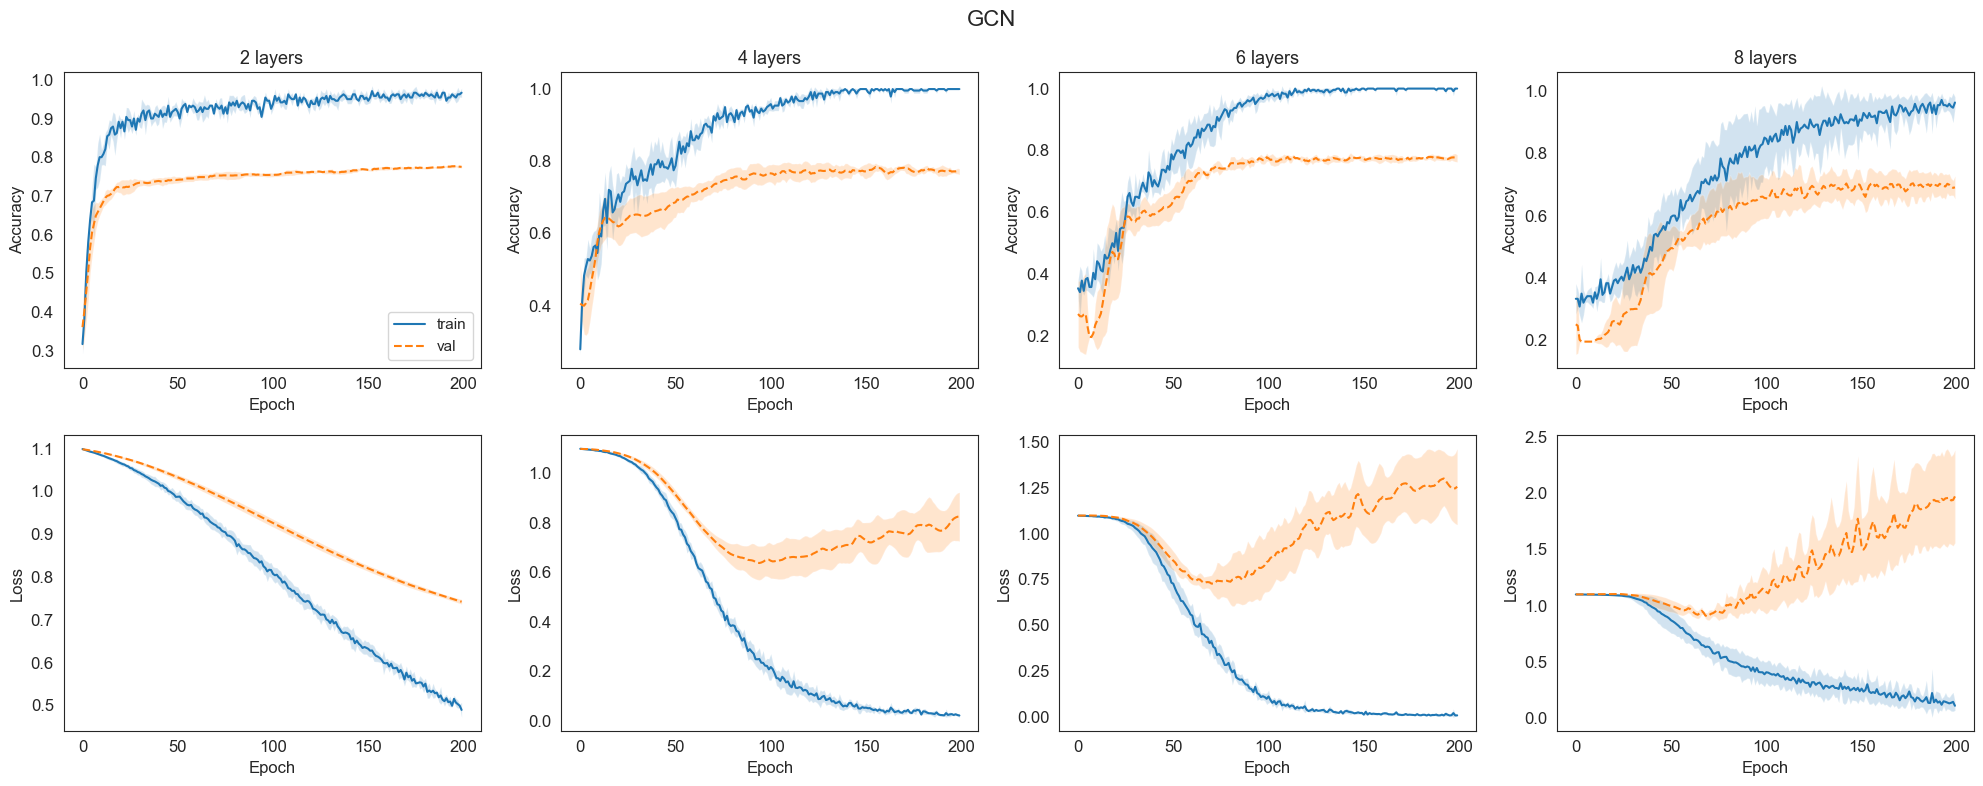

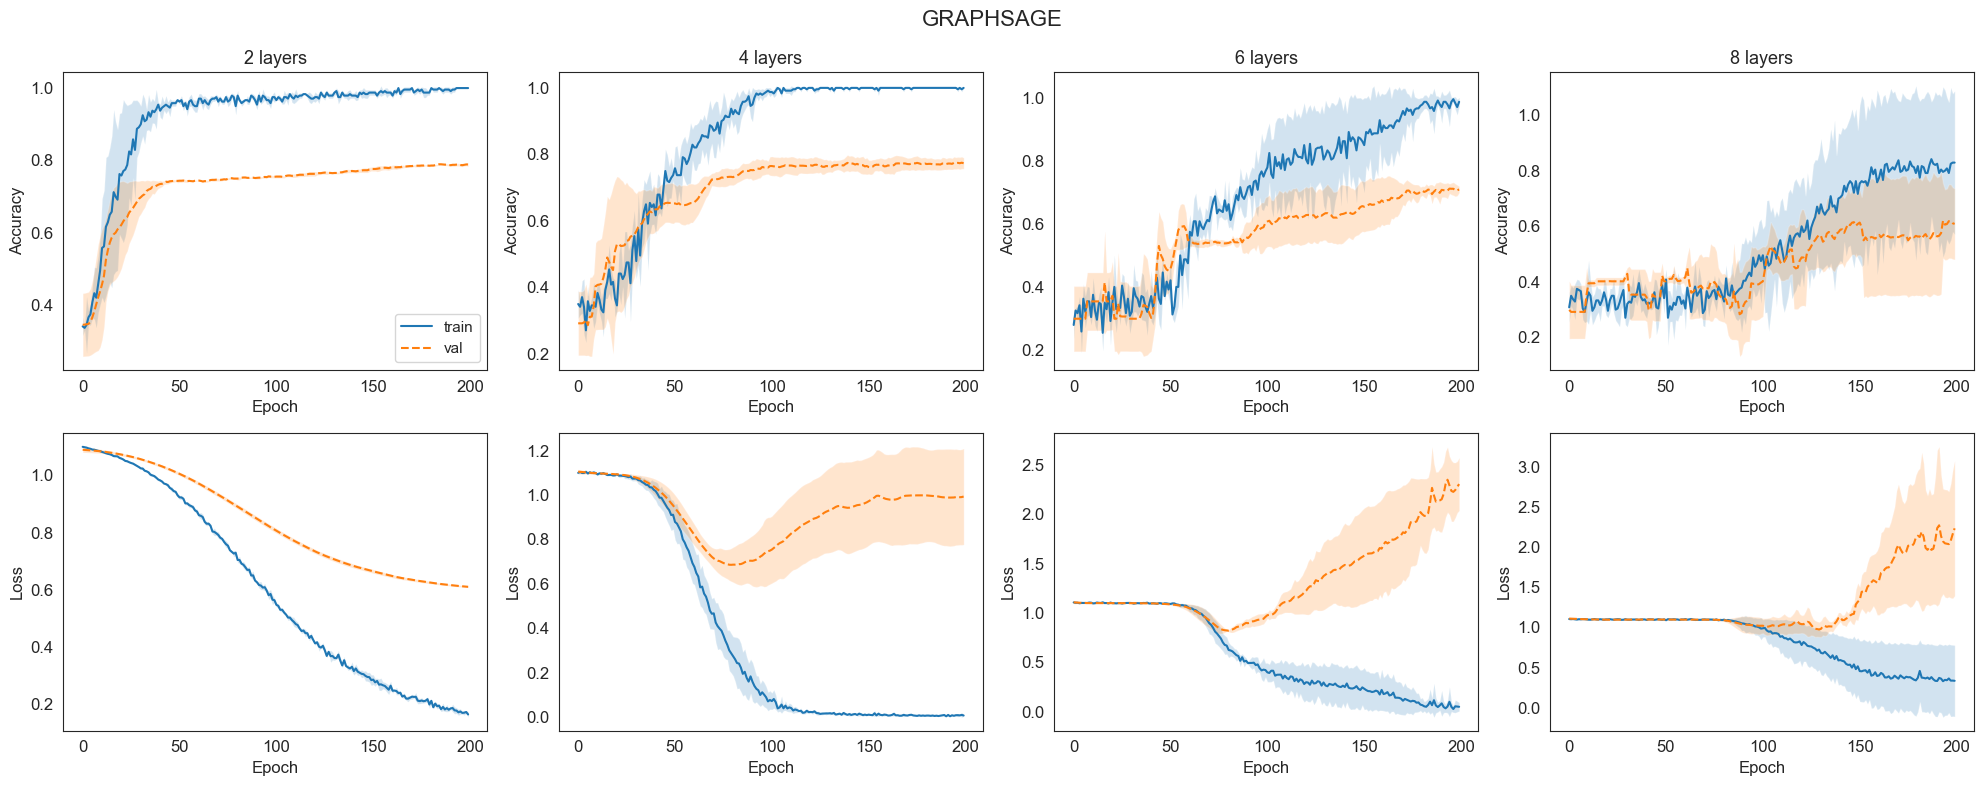

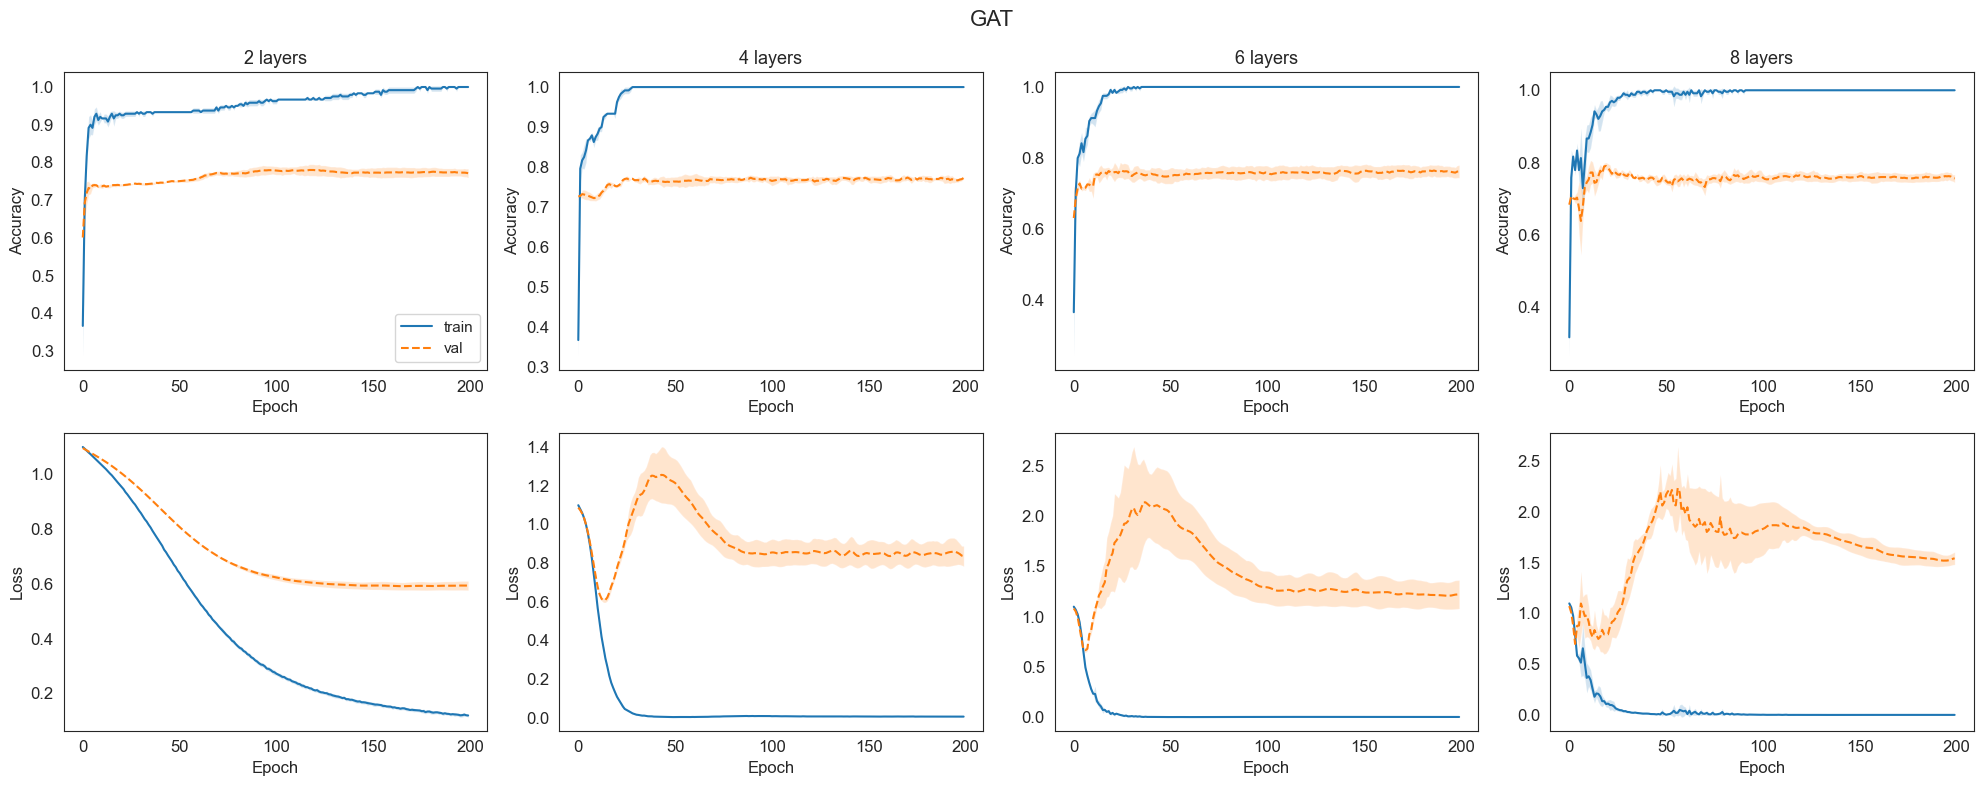

In [8]:
plot_by_model(history, "gcn")
plot_by_model(history, "graphsage")
plot_by_model(history, "gat")

In [9]:
colors = {
    "gcn": "#4C72B0",
    "graphsage": "#55A868",
    "gat": "#C44E52"
}

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

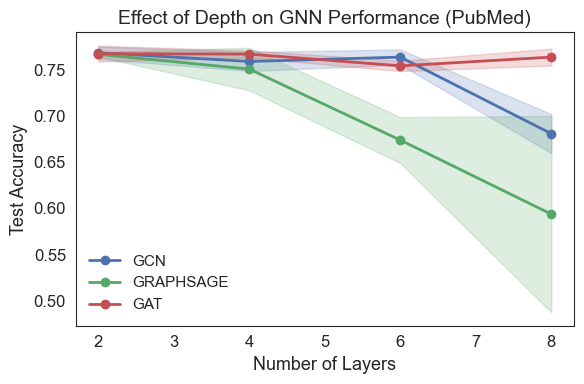

In [10]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    layers = data["layers"]
    mean = np.array(data["acc_mean"])
    std = np.array(data["acc_std"])

    plt.plot(
        layers,
        mean,
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

    # banda de variabilidad (mean ± std)
    plt.fill_between(
        layers,
        mean - std,
        mean + std,
        color=colors[model],
        alpha=0.2
    )

plt.xlabel("Number of Layers")
plt.ylabel("Test Accuracy")

plt.title("Effect of Depth on GNN Performance (PubMed)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../../results/plots/pubmed/accuracy_vs_layers.png", dpi=300)

plt.show()

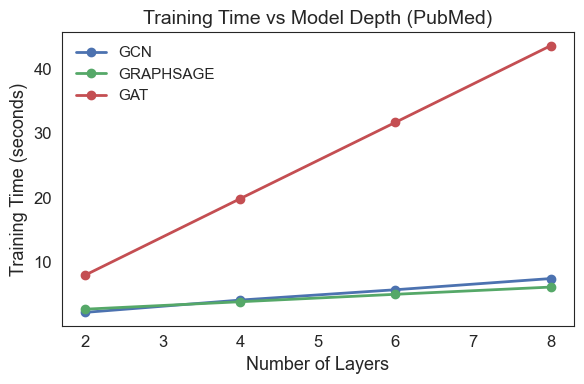

In [11]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    plt.plot(
        data["layers"],
        data["time"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

plt.xlabel("Number of Layers")
plt.ylabel("Training Time (seconds)")

plt.title("Training Time vs Model Depth (PubMed)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../../results/plots/pubmed/time_vs_layers.png", dpi=300)

plt.show()

In [12]:
rows = []
for model in results:
    for i in range(len(results[model]["layers"])):
        rows.append({
            "model": model,
            "layers": results[model]["layers"][i],
            "accuracy_mean": results[model]["acc_mean"][i],
            "accuracy_std": results[model]["acc_std"][i],
            "time": results[model]["time"][i]
        })

df = pd.DataFrame(rows)
df.to_csv("../../results/tables/pubmed/gnn_layer_experiments.csv", index=False)

In [13]:
with open("../../results/tables/pubmed/gnn_layer_experiments.json", "w") as f:
    json.dump(results, f, indent=4)

with open("../../results/tables/pubmed/history.json", "w") as f:
    json.dump(history, f, indent=4)

## Graph Structural Properties

Oversquashing is closely related to structural bottlenecks in the graph. Intuitively, if many nodes must communicate through a small number of edges, information from distant parts of the graph becomes compressed as it propagates.

One way to explore this is to analyze how the size of a node's neighborhood grows as the number of hops increases.

In [4]:
G = to_networkx(data, to_undirected=True)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print("Average degree:", avg_degree)

Number of nodes: 19717
Number of edges: 44324
Average degree: 4.496018664096972


## Neighborhood Growth

If information could propagate freely through the graph, the number of reachable nodes should grow rapidly as the number of hops increases.

However, in graphs with structural bottlenecks, this expansion may be much slower. This means that information from large parts of the graph must be compressed through a limited number of edges, which is precisely the mechanism behind oversquashing.

The following analysis measures how the size of node neighborhoods grows as the hop distance increases.

In [5]:
from collections import deque

def k_hop_neighbors(G, start, k):
    
    visited = {start}
    queue = deque([(start, 0)])
    
    while queue:
        node, depth = queue.popleft()
        
        if depth == k:
            continue
            
        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, depth + 1))
                
    return len(visited)

sample_nodes = random.sample(list(G.nodes()), 200)

max_k = 12
growth = []

for k in range(1, max_k + 1):
    
    sizes = []
    
    for node in sample_nodes:
        sizes.append(k_hop_neighbors(G, node, k))
        
    growth.append(sum(sizes) / len(sizes))

## Expansion of k-hop neighborhoods

The following plot shows how the average number of reachable nodes grows with increasing hop distance.

If the expansion saturates quickly, it suggests that the graph contains structural bottlenecks that may restrict information flow.

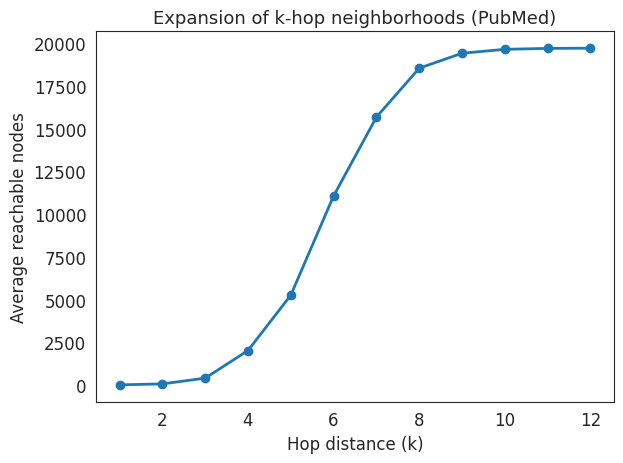

In [6]:
plt.figure()

plt.plot(
    range(1, max_k + 1),
    growth,
    marker="o",
    linewidth=2,
)

plt.xlabel("Hop distance (k)")
plt.ylabel("Average reachable nodes")

plt.title("Expansion of k-hop neighborhoods (PubMed)")

plt.tight_layout()

plt.savefig(
    "../../results/plots/pubmed/khop_neighborhood_growth.png",
    dpi=300
)

plt.show()

## Local Bottlenecks via Edge Betweenness Centrality

In [ ]:
values = np.array(list(nx.edge_betweenness_centrality(G).values()))

plt.figure()

sns.histplot(
    values,
    bins=40,
    kde=False
)

plt.xlabel("Edge betweenness centrality")
plt.ylabel("Number of edges")

plt.title("Distribution of edge betweenness (PubMed)")

plt.tight_layout()

plt.savefig(
    "../../results/plots/pubmed/edge_betweenness_distribution.png",
    dpi=300
)

plt.show()

In [ ]:
top_values = np.sort(values)[-20:]

plt.figure()

plt.plot(
    range(1, len(top_values)+1),
    top_values,
    marker="o",
    linewidth=2
)

plt.xlabel("Top-ranked edges")
plt.ylabel("Edge betweenness centrality")

plt.title("Highest-betweenness edges (PubMed)")

plt.tight_layout()

plt.savefig(
    "../../results/plots/pubmed/highest_betweenness_edges.png",
    dpi=300
)

plt.show()